# Antikythera Mechanism: Computing in Bronze

Before silicon, before electricity, and long before stored-program computers, someone built a machine that turned astronomy into gear motion.

The Antikythera Mechanism was a Hellenistic bronze gearwork device recovered from a shipwreck near the island of Antikythera. It probably dates to the second or early first century BCE. Modern reconstructions treat it as an astronomical calculator: it displayed calendar cycles, solar and lunar motion, lunar phase, and eclipse-related cycles.

In this notebook, the point is not just history. The point is to ask:

> What counts as a computer?

The mechanism gives a beautiful answer: computation is not electricity. Computation is state plus rules.


## 1. Mental Model

A modern program stores numbers in memory and applies instructions. The Antikythera Mechanism stored numbers as angles and applied instructions as gear ratios.

For this course, it introduces three foundational ideas:

- **Deterministic state**: one crank position determines every connected dial.
- **Algorithms as ratios**: gears multiply and divide rotations using tooth counts.
- **Hardware as code**: the program is carved into bronze.

This is an analog computer. Its state changes continuously as the crank turns, but the relationships between parts are precise and rule-bound.

A careful historical note: the mechanism was not using a modern heliocentric model. It displayed apparent motions of the Sun and Moon as seen from Earth. In this notebook, we use modern astronomical words like "solar year" and "lunar month" as convenient labels for the cycles being modeled.


## 2. The Cycles Hidden in the Gears

Ancient astronomers knew that lunar and solar cycles almost line up after certain integer counts.

| Cycle | Relationship | Notebook role |
| --- | ---: | --- |
| Synodic month | about 29.53059 days | New Moon to New Moon; controls lunar phase |
| Tropical year | about 365.2422 days | Seasonal solar year |
| Metonic cycle | 235 lunar months in 19 years | Keeps lunar months aligned with solar years |
| Saros cycle | 223 lunar months | Eclipses recur in similar geometry |
| Exeligmos | 3 Saros cycles | Saros shifted by about 8 hours each time, so three cycles brings eclipses closer to the same time of day |

The clean computational miracle is the Metonic ratio:

```text
235 synodic lunar months / 19 solar years
```

That means a lunar-phase pointer should gain `235/19` turns relative to the Sun for each full solar-year turn.

In [1]:
from __future__ import annotations

from fractions import Fraction
from math import floor

TROPICAL_YEAR_DAYS = 365.2422
SYNODIC_MONTH_DAYS = 29.53059
SAROS_MONTHS = 223
EXELIGMOS_MONTHS = 3 * SAROS_MONTHS

observed_lunations_per_year = TROPICAL_YEAR_DAYS / SYNODIC_MONTH_DAYS
metonic_ratio = Fraction(235, 19)

print("Observed lunations per year:", round(observed_lunations_per_year, 6))
print("Metonic ratio:", metonic_ratio, "=", round(float(metonic_ratio), 6))
print("Error per year:", round(float(metonic_ratio) - observed_lunations_per_year, 6), "lunations")


Observed lunations per year: 12.368266
Metonic ratio: 235/19 = 12.368421
Error per year: 0.000155 lunations


## 3. Gear Ratios as Fraction Machines

If a gear with `p` teeth drives a gear with `q` teeth, the driven gear turns by `p/q` rotations for each rotation of the driver. Meshed gears reverse direction, but for calendar dials we often care about the magnitude of the rotation.

One reconstructed lunar train uses this exact product:

```text
64/38 * 48/24 * 127/32 = 254/19
```

This is a sidereal lunar ratio: about `13.368421` Moon-against-stars rotations per solar year.

Why does the Metonic lunar-phase ratio appear?

```text
Moon relative to Sun = sidereal Moon rotations - solar rotation
                     = 254/19 - 1
                     = 235/19
```

That is the computational bridge: a gear train can track one angular motion, and the display can compare it with another.


In [2]:
from __future__ import annotations

lunar_sidereal_ratio = Fraction(64, 38) * Fraction(48, 24) * Fraction(127, 32)
lunar_phase_ratio = lunar_sidereal_ratio - 1

print("Sidereal lunar gear ratio:", lunar_sidereal_ratio, "=", float(lunar_sidereal_ratio))
print("Moon phase ratio after subtracting the Sun:", lunar_phase_ratio, "=", float(lunar_phase_ratio))
print("Matches Metonic 235/19:", lunar_phase_ratio == metonic_ratio)


Sidereal lunar gear ratio: 254/19 = 13.368421052631579
Moon phase ratio after subtracting the Sun: 235/19 = 12.368421052631579
Matches Metonic 235/19: True


## 4. Build the Gear Objects

The model below is intentionally small. It does not reconstruct every gear or the famous pin-and-slot lunar anomaly mechanism. Instead, it focuses on the foundational computer-science idea:

> connected parts propagate state by deterministic rules.

We will model:

- a driving gear,
- meshed gears that turn in the opposite direction,
- compound gears locked on the same axle,
- exact ratios stored as `Fraction` objects.


**Object model.** Define `Connection`, the named objects used by the next examples.


In [ ]:
from __future__ import annotations

from dataclasses import dataclass, field

@dataclass
class Connection:
    child: "Gear"
    ratio: Fraction
    label: str


**Object model.** Define `Gear`, the named objects used by the next examples.


In [ ]:
from __future__ import annotations

@dataclass
class Gear:
    name: str
    teeth: int
    angle: float = 0.0
    connections: list[Connection] = field(default_factory=list)

    def mesh_with(self, child: "Gear", label: str = "") -> None:
        ratio = -Fraction(self.teeth, child.teeth)
        self.connections.append(Connection(child, ratio, label or f"{self.name}->{child.name}"))

    def lock_to_axle(self, child: "Gear", label: str = "") -> None:
        self.connections.append(Connection(child, Fraction(1, 1), label or f"{self.name} axle {child.name}"))

    def turn(self, degrees: float, trace: list[dict] | None = None, depth: int = 0) -> None:
        self.angle = (self.angle + degrees) % 360
        if trace is not None:
            trace.append({
                "depth": depth,
                "gear": self.name,
                "teeth": self.teeth,
                "degrees": degrees,
                "angle": self.angle,
            })
        for connection in self.connections:
            connection.child.turn(degrees * float(connection.ratio), trace, depth + 1)

    def reset(self) -> None:
        self.angle = 0.0
        for connection in self.connections:
            connection.child.reset()


## 5. Assemble a Teaching Version of the Lunar Train

The gears below encode the ratio:

```text
b1 -> c1: 64/38
c2 -> d1: 48/24
d2 -> e2: 127/32
```

`c1` and `c2` are locked on the same axle, as are `d1` and `d2`. That lets one meshed gear pass its rotation to another gear without changing the angle.

The sign flips show direction changes from gear meshes. The magnitude gives the computed astronomical ratio.


**Builder helper.** Define `build_lunar_train`, which prepares reusable examples or traces.


In [ ]:
from __future__ import annotations

def build_lunar_train():
    b1 = Gear("b1 main solar drive", 64)
    c1 = Gear("c1", 38)
    c2 = Gear("c2", 48)
    d1 = Gear("d1", 24)
    d2 = Gear("d2", 127)
    e2 = Gear("e2 lunar sidereal output", 32)

    b1.mesh_with(c1, "64 drives 38")
    c1.lock_to_axle(c2, "same axle")
    c2.mesh_with(d1, "48 drives 24")
    d1.lock_to_axle(d2, "same axle")
    d2.mesh_with(e2, "127 drives 32")

    return b1, {"b1": b1, "c1": c1, "c2": c2, "d1": d1, "d2": d2, "e2": e2}

crank, gears = build_lunar_train()

trace = []

crank.turn(360, trace)

for row in trace:
    indent = "  " * row["depth"]
    print(f'{indent}{row["gear"]:28s} teeth={row["teeth"]:3d} turned={row["degrees"]:9.2f} angle={row["angle"]:7.2f}')

print()


**Inspect the result.** Evaluate the expression and read the output before changing parameters.


In [ ]:
from __future__ import annotations

print("Output turns per solar turn:", round(trace[-1]["degrees"] / 360, 6))

print("Expected signed ratio:", -float(lunar_sidereal_ratio))


## 6. Crank State: Calendar, Moon Phase, and Saros Return

Now turn the main crank by a number of days.

We will calculate:

- solar angle through the year,
- Moon phase fraction,
- phase name,
- Saros position.

The Saros warning here means: **if day 0 begins at an eclipse in one eclipse family, then a similar eclipse geometry recurs every 223 synodic months**. The historical mechanism used a Saros spiral with inscribed eclipse information; this notebook models the cycle logic, not the full inscription catalog.


**Helper functions.** Define `phase_name` so the later cells stay focused on behavior.


In [ ]:
from __future__ import annotations

PHASE_NAMES = [
    "New Moon",
    "Waxing Crescent",
    "First Quarter",
    "Waxing Gibbous",
    "Full Moon",
    "Waning Gibbous",
    "Last Quarter",
    "Waning Crescent",
]

def phase_name(fraction: float) -> str:
    index = int((fraction * 8) + 0.5) % 8
    return PHASE_NAMES[index]


**Helper functions.** Define `mechanism_state` so the later cells stay focused on behavior.


In [ ]:
from __future__ import annotations

def mechanism_state(days: float) -> dict:
    solar_years = days / TROPICAL_YEAR_DAYS
    synodic_months = solar_years * float(metonic_ratio)
    sidereal_moon_turns = solar_years * float(lunar_sidereal_ratio)
    moon_phase_fraction = synodic_months % 1
    saros_position = synodic_months % SAROS_MONTHS
    saros_return = min(saros_position, SAROS_MONTHS - saros_position)

    return {
        "days": days,
        "solar_day": (days % TROPICAL_YEAR_DAYS),
        "solar_angle": (solar_years % 1) * 360,
        "sidereal_moon_angle": (sidereal_moon_turns % 1) * 360,
        "moon_phase_fraction": moon_phase_fraction,
        "moon_phase_angle": moon_phase_fraction * 360,
        "moon_phase": phase_name(moon_phase_fraction),
        "synodic_months": synodic_months,
        "saros_position": saros_position,
        "saros_return_warning": saros_return < 0.25,
    }


**Run the experiment.** Advance the algorithm and collect the state changes that make the behavior visible.


In [ ]:
from __future__ import annotations

for days in [0, 29.53, 365.24, 19 * 365.2422, 223 * 29.53059]:
    state = mechanism_state(days)
    print(
        f'{days:8.2f} days | phase={state["moon_phase"]:16s} | '
        f'synodic months={state["synodic_months"]:8.2f} | '
        f'Saros position={state["saros_position"]:7.2f} | '
        f'warning={state["saros_return_warning"]}'
    )


## 7. Visual Dials

The real device used pointers and spiral dials. Our teaching display uses three simple panels:

- **Solar year dial**: where the crank is in the year.
- **Moon phase dial**: New Moon to Full Moon and back.
- **Saros dial**: position inside the 223-month eclipse cycle.

This is the same idea as the rest of the course: make state visible.


**Helper functions.** Define `pointer`, `setup_dial` so the later cells stay focused on behavior.


In [ ]:
from __future__ import annotations

import math

import matplotlib.pyplot as plt

from matplotlib.patches import Circle, Wedge

def pointer(ax, angle_degrees: float, radius: float, color: str, label: str) -> None:
    angle = math.radians(90 - angle_degrees)
    x = radius * math.cos(angle)
    y = radius * math.sin(angle)
    ax.plot([0, x], [0, y], color=color, linewidth=3)
    ax.scatter([x], [y], color=color, s=60)
    ax.text(0, -1.25, label, ha="center", va="center", fontsize=10)

def setup_dial(ax, title: str) -> None:
    ax.set_aspect("equal")
    ax.add_patch(Circle((0, 0), 1.0, fill=False, linewidth=2, color="#334155"))
    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)
    ax.axis("off")
    ax.set_title(title, fontsize=12)


**Visual helper.** Define `draw_mechanism`, which turns state into something students can inspect.


In [ ]:
from __future__ import annotations

def draw_mechanism(days: float = 365.2422) -> None:
    state = mechanism_state(days)
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    setup_dial(axes[0], "Solar year")
    pointer(axes[0], state["solar_angle"], 0.9, "#f59e0b", f'day {state["solar_day"]:.1f}')

    setup_dial(axes[1], "Moon phase")
    axes[1].add_patch(Wedge((0, 0), 0.95, 90, 270, color="#e5e7eb", alpha=0.95))
    axes[1].add_patch(Wedge((0, 0), 0.95, 270, 90, color="#111827", alpha=0.95))
    pointer(axes[1], state["moon_phase_angle"], 0.88, "#38bdf8", state["moon_phase"])

    setup_dial(axes[2], "Saros cycle")
    saros_angle = (state["saros_position"] / SAROS_MONTHS) * 360
    color = "#ef4444" if state["saros_return_warning"] else "#22c55e"
    pointer(axes[2], saros_angle, 0.9, color, f'{state["saros_position"]:.1f} / 223 months')
    if state["saros_return_warning"]:
        axes[2].text(0, 1.18, "Saros return window", ha="center", va="center", color="#ef4444", fontsize=10)

    fig.suptitle(f"Antikythera teaching model after {days:,.1f} crank-days", fontsize=14)
    plt.tight_layout()
    plt.show()


**Inspect the result.** Evaluate the expression and read the output before changing parameters.


In [ ]:
from __future__ import annotations

draw_mechanism(365.2422)


## 8. Interactive Crank

If `ipywidgets` is available, use the slider. If not, run the fallback examples below.


Interactive widgets are not available in this environment.
Fallback frames:


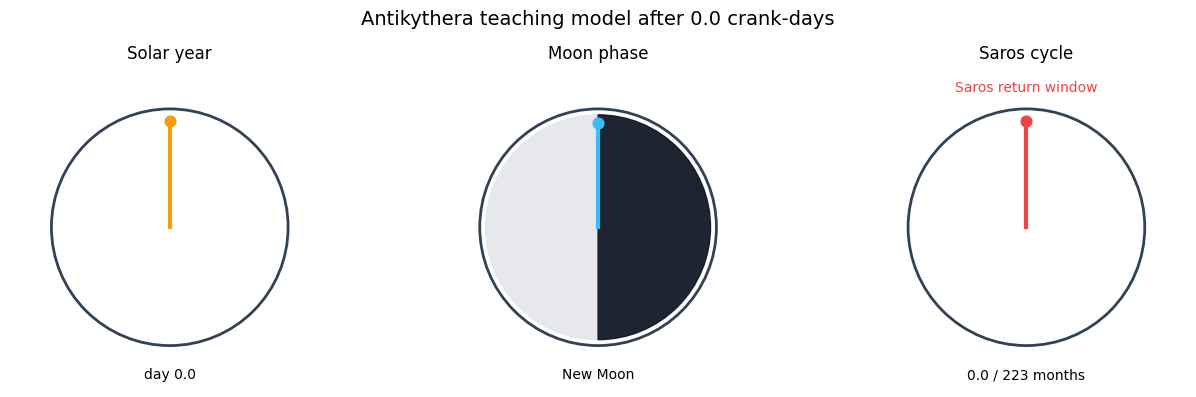

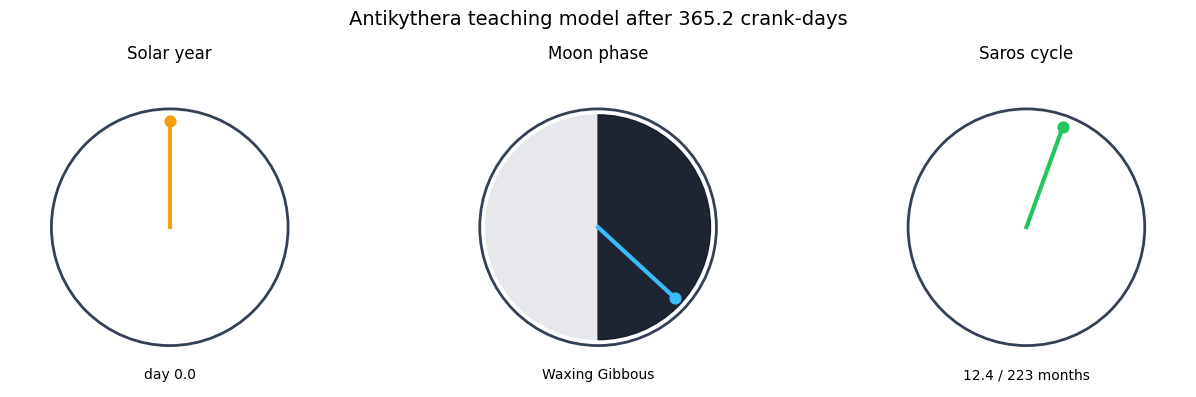

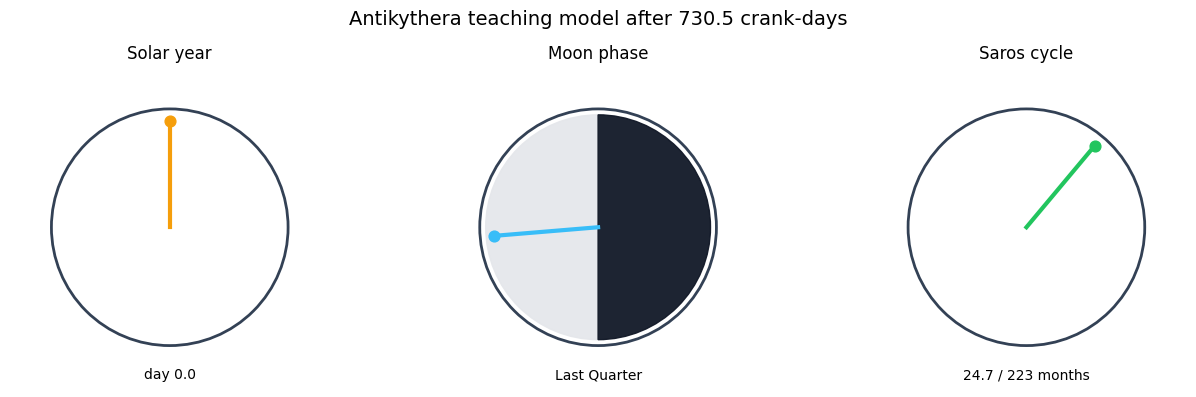

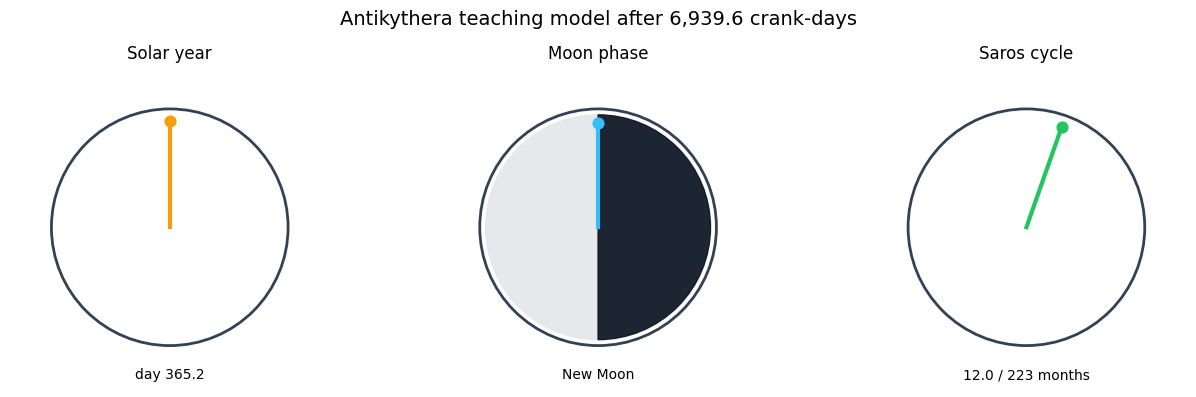

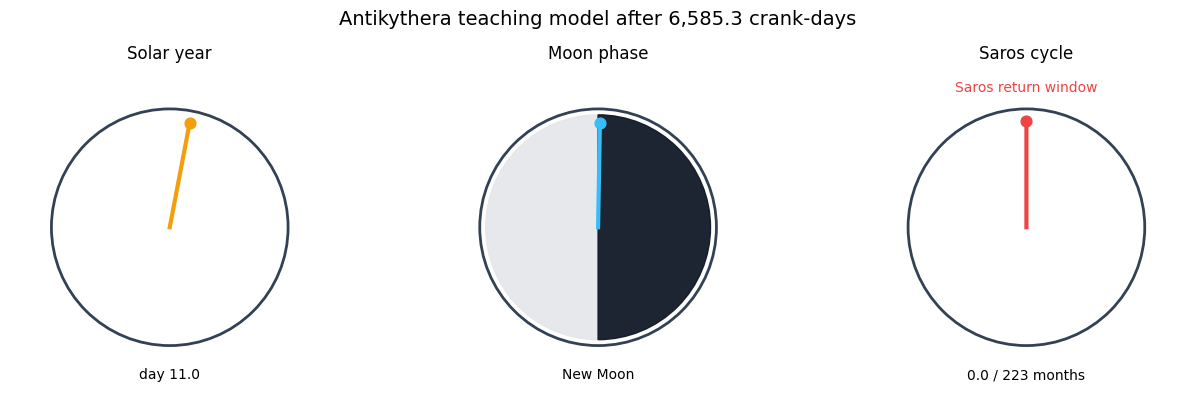

In [7]:
from __future__ import annotations

try:
    import ipywidgets as widgets
    from IPython.display import display

    slider = widgets.FloatSlider(
        value=365.2422,
        min=0,
        max=223 * SYNODIC_MONTH_DAYS,
        step=7,
        description="Crank days",
        continuous_update=False,
        readout_format=".1f",
        style={"description_width": "initial"},
    )
    output = widgets.interactive_output(draw_mechanism, {"days": slider})
    display(slider, output)
except Exception as exc:
    print("Interactive widgets are not available in this environment.")
    print("Fallback frames:")
    for days in [0, 365.2422, 2 * 365.2422, 19 * 365.2422, 223 * SYNODIC_MONTH_DAYS]:
        draw_mechanism(days)


## 9. Playground: Find Good Gear Fractions

Gear teeth must be integers. So the design problem becomes:

> Which integer fractions approximate the astronomy well enough, while still being buildable?

`Fraction.limit_denominator` is a modern helper for a very old idea: find a useful rational approximation.


In [8]:
from __future__ import annotations

actual = observed_lunations_per_year

for max_denominator in [5, 10, 20, 50, 100, 300]:
    approximation = Fraction(actual).limit_denominator(max_denominator)
    error = float(approximation) - actual
    print(
        f"max denominator {max_denominator:3d}: "
        f"{approximation!s:>8s} = {float(approximation):.8f} "
        f"error={error:+.8f}"
    )


max denominator   5:     62/5 = 12.40000000 error=+0.03173374
max denominator  10:     99/8 = 12.37500000 error=+0.00673374
max denominator  20:   235/19 = 12.36842105 error=+0.00015479
max denominator  50:   235/19 = 12.36842105 error=+0.00015479
max denominator 100:   235/19 = 12.36842105 error=+0.00015479
max denominator 300: 3661/296 = 12.36824324 error=-0.00002302


## 10. Mini-Challenge

Try one:

1. Change the gear train tooth counts and see how close you can get to `254/19`.
2. Change the crank to `19` years and explain why the Moon phase nearly returns.
3. Change the crank to one Saros cycle and explain what the warning means.
4. Build a tiny trace table: days, phase, Saros position, warning.

The important habit is the same as every notebook in this course:

**predict, run, observe, transfer.**


In [9]:
from __future__ import annotations

candidate_trains = [
    (64, 38, 48, 24, 127, 32),
    (60, 38, 48, 24, 127, 32),
    (64, 40, 48, 24, 127, 32),
]

target = Fraction(254, 19)

for train in candidate_trains:
    b1, c1, c2, d1, d2, e2 = train
    ratio = Fraction(b1, c1) * Fraction(c2, d1) * Fraction(d2, e2)
    print(train, "ratio=", ratio, "error=", float(ratio - target))


(64, 38, 48, 24, 127, 32) ratio= 254/19 error= 0.0
(60, 38, 48, 24, 127, 32) ratio= 1905/152 error= -0.8355263157894737
(64, 40, 48, 24, 127, 32) ratio= 127/10 error= -0.6684210526315789


## Visual Trace + Rigor Studio

**Problem frame.** Model computation as physical state changing through deterministic gear ratios.

**Interactive animation target.** Animate the crank, gear train, solar dial, Moon phase dial, and Saros-cycle position.

**Correctness handle.** A gear connection preserves the invariant `child rotation = parent rotation * parent teeth / child teeth`, with sign determined by meshing direction.

**Complexity handle.** A tree-shaped gear simulation is `O(G)` per crank update for `G` gears. The real historical challenge was not runtime; it was encoding accurate astronomical ratios in manufacturable bronze teeth.

**Failure mode to test.** Change one tooth count by 1 and measure how phase error accumulates over 19 years.

**Studio task.** Explain how `254/19 - 1 = 235/19` connects a sidereal lunar pointer to a lunar-phase display.


**Run the experiment.** Advance the algorithm and collect the state changes that make the behavior visible.


In [ ]:
from __future__ import annotations

from pathlib import Path

import sys

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "courseware").exists():
        sys.path.insert(0, str(candidate))
        break


**Interactive display.** Build the widget path when available, with a notebook-friendly fallback.


In [ ]:
from __future__ import annotations

try:
    from IPython.display import display
    from courseware import AlgorithmTrace, render_trace_table

    trace = AlgorithmTrace(
        "Antikythera crank trace",
        objective="Track visible calendar state as crank-days increase.",
        complexity="O(1) for this closed-form dial model; O(G) for a gear graph with G gears.",
    )

    for days in [0, 29.53059, 365.2422, 19 * 365.2422, 223 * 29.53059]:
        state = mechanism_state(days)
        trace.append(
            f"{days:.1f} days",
            state,
            f'{state["moon_phase"]}; Saros position {state["saros_position"]:.2f}',
            metrics={
                "solar_angle": round(state["solar_angle"], 2),
                "moon_phase_angle": round(state["moon_phase_angle"], 2),
                "saros_warning": state["saros_return_warning"],
            },
            invariant="Crank-days determine every displayed dial.",
            operation="advance crank",
        )

    display(render_trace_table(trace))
except Exception as exc:
    print("Courseware trace table unavailable:", exc)


## Sources and Further Reading

This notebook uses a simplified teaching model. For historical and reconstruction details, start here:

- Institute for the Study of the Ancient World, [The Antikythera Mechanism](https://isaw.nyu.edu/research/antikythera-mechanism)
- Freeth et al., [Decoding the ancient Greek astronomical calculator known as the Antikythera Mechanism](https://www.nature.com/articles/nature05357), Nature 444, 587-591 (2006)
- Freeth et al., [Calendars with Olympiad display and eclipse prediction on the Antikythera mechanism](https://www.nature.com/articles/nature07130), Nature 454, 614-617 (2008)
- Freeth and Jones, [The Cosmos in the Antikythera Mechanism](https://isaw.nyu.edu/publications/isaw-papers/4), ISAW Papers 4 (2012)
- Freeth, [Our current knowledge of the Antikythera Mechanism](https://www.nature.com/articles/s41550-017-0347-2), Nature Astronomy 1, 858-870 (2017)
- Freeth et al., [Nature 2006 supplementary material](https://www.antikythera-mechanism.gr/system/files/0608_Nature-Supplementary.pdf), including gear-ratio conventions and reconstructed trains

The exact front display remains an active scholarly topic, especially for planetary displays. The lesson here sticks to secure course-relevant ideas: state, ratios, cycles, deterministic propagation, and the Metonic/Saros logic.
